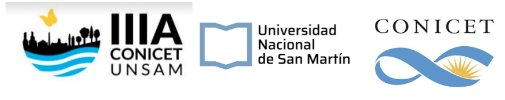  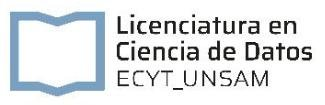

---

# NB08 — Aprendizaje supervisado: clasificación de coberturas

Lo que veremos en esta notebook:

- [x] La tarea de clasificar y qué pide de los datos
- [x] K-Nearest Neighbors y árboles de decisión como referencias conceptuales
- [x] Random Forest: bagging, aleatorización y su adecuación a teledetección
- [x] Evaluación cruzada espacial: por qué K-fold estándar infla la precisión
- [x] Coeficiente de Cohen Kappa y lectura de la matriz de confusión
- [x] Importancia de features: interpretabilidad con sus limitaciones
- [x] Producción del mapa de cobertura sobre la imagen completa
---

### Objetivos de la notebook

Al terminar esta clase esperamos que puedas:

- Entrenar un clasificador Random Forest a nivel de píxel sobre un dataset multibanda con etiquetas.
- Diseñar una evaluación cruzada **por grupos espaciales** que evite optimismo por dependencia entre muestras cercanas.
- Interpretar correctamente Kappa, matriz de confusión, precisión por clase.
- Reflejar las limitaciones de la importancia de features en presencia de colinealidad.
- Aplicar un modelo entrenado a la imagen completa y generar un mapa de cobertura.

### Datos con los que trabajaremos

- `../data/proc/dataset_etiquetado_corregido.npz` — $(X, y, \text{ids\_roi})$ construido en la pipeline de etiquetado y corregido en el EDA del dataset (6 features × 6 clases).
- `../data/raw_data/satelital/S2_AMBANO_B02B03B04B08_2026feb.tif` — imagen para predecir.
- `../data/proc/mapa_cluster_gmm_dique_2026feb.tif` — mapa GMM del clustering, para comparar.

### Conexión con el arco del curso

Esta es la contraparte supervisada del clustering. El orden —no supervisado primero, supervisado después— no es casual: ahora podemos contrastar **lo que la imagen deja emerger espontáneamente** (clusters GMM) con **lo que nuestro esquema conceptual impone** (6 clases humanas). Cuando ambos mapas coinciden, la clase tiene un sustento espectral sólido; donde difieren, hay algo para aprender sobre el territorio o sobre el esquema.

El mapa de cobertura es un producto central del curso: las próximas notebooks lo evalúan rigurosamente, lo usan para detectar cambios comparando con 2015, y lo integran como contexto al análisis por radio censal.

---
# 0. Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.mask import mask as rasterio_mask
import geopandas as gpd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, StratifiedGroupKFold,
                                       cross_val_score, cross_val_predict)
from sklearn.metrics import (classification_report, confusion_matrix,
                               cohen_kappa_score, accuracy_score)
from sklearn.preprocessing import StandardScaler
import joblib

from ade_tools import componer_rgb, guardar_geotiff

RAW  = '../data/raw_data/'
PROC = '../data/proc/'
OUT  = '../data/out/'

FN_IMG  = RAW + 'satelital/S2_AMBANO_B02B03B04B08_2026feb.tif'
FN_ZONA = RAW + 'vectorial/zona_dique.geojson'

# CLASES_ORD se deriva del dataset corregido al cargarlo — ver sección 1

---
# 1. La tarea de clasificación

Un problema de clasificación supervisada busca una función $f: X \to y$ que asigne a cada observación $x \in \mathbb{R}^d$ una etiqueta $y$ de un conjunto finito de categorías, aprendida a partir de ejemplos etiquetados $\{(x_i, y_i)\}_{i=1}^n$.

En teledetección a nivel de píxel:

- $x_i$ = vector espectral del píxel $i$ (en nuestro caso 6 dimensiones: 4 bandas + 2 índices).
- $y_i$ = clase de cobertura asignada por un intérprete humano o por un mapa de referencia.
- $f$ = el clasificador entrenado que usamos para mapear todos los píxeles de una imagen.

### Supuestos implícitos que conviene recordar

1. **Las clases están definidas adecuadamente.** Si la clase `urbano` incluye cosas físicamente heterogéneas (techos, calles, patios, vegetación urbana), la firma espectral de la clase va a ser intrínsecamente amplia y difícil de aprender.

2. **Las muestras de entrenamiento son representativas.** Si solo tomamos ROIs en el norte del territorio, el modelo puede fallar en el sur.

3. **Los píxeles son independientes.** Falso. Los píxeles vecinos están altamente correlacionados por la continuidad del paisaje. La consecuencia operativa es que **K-fold estándar subestima el error** del modelo: todos los folds ven las mismas regiones. Discutimos esto más abajo.

In [ ]:
# Cargamos el dataset etiquetado corregido (con la subdivisión rural producida en el EDA)
data = np.load(PROC + 'dataset_etiquetado_corregido.npz', allow_pickle=True)
X = data['X']
y = data['y']
ids_roi = data['ids_roi']
nombres_features = data['nombres_features'].tolist()

# Orden canónico derivado del dataset (alfabético): los nombres de las dos
# subclases rurales fueron elegidos por el alumno al subdividir rural en el EDA.
CLASES_ORD = tuple(sorted(np.unique(y)))

print(f'X: {X.shape}   y: {y.shape}   ids_roi: {ids_roi.shape}')
print(f'Features: {nombres_features}')
print(f'Clases  : {CLASES_ORD}   ({len(CLASES_ORD)} clases)')
print(f'ROIs distintos en total: {len(np.unique(ids_roi))}')
print(f'\nRatio min/max de ejemplos por clase: '
      f'{pd.Series(y).value_counts().min() / pd.Series(y).value_counts().max():.3f}')

---
# 2. Tres clasificadores en una figura

Comparamos brevemente tres familias antes de elegir Random Forest.

### 2.1 K-Nearest Neighbors

Para clasificar un punto nuevo, mira los $k$ puntos de entrenamiento más cercanos y lo etiqueta por votación. No hay entrenamiento propiamente dicho (*lazy learning*). Es extremadamente transparente y suele ser un benchmark útil — si un clasificador sofisticado apenas supera a KNN, es señal de que la mejora potencial no es tanta.

### 2.2 Árbol de decisión

Particiona el espacio de features con cortes ortogonales sucesivos, cada corte elegido para maximizar una ganancia de información. Interpretable pero **inestable**: pequeños cambios en los datos pueden dar árboles muy distintos. Solo tiende a ser buen modelo final cuando es muy profundo, y entonces sobreajusta.

### 2.3 Random Forest

Un **ensamble** de muchos árboles (típicamente $\sim 100$), cada uno entrenado sobre un *bootstrap* de los datos y usando en cada nodo un subconjunto aleatorio de features (Breiman, 2001). Las predicciones se promedian (por votación). El ensamblaje:

- **Reduce varianza** dramáticamente (corrige la inestabilidad del árbol individual).
- **Maneja bien datos de alta dimensión** con features correlacionadas.
- Es **robusto a hiperparámetros** — funciona razonablemente bien con valores por defecto.

En teledetección óptica, Random Forest se convirtió en el baseline estándar durante la última década. Belgiu & Drăguţ (2016, *ISPRS J. Photogrammetry*) revisan extensivamente su uso en el área.

In [ ]:
# Comparación rápida con K-fold estándar (ya veremos por qué es optimista)
clfs = {
    'KNN (k=5)'    : KNeighborsClassifier(n_neighbors=5),
    'Árbol'         : DecisionTreeClassifier(max_depth=15, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Accuracy (K-fold 5, estratificado por clase — SESGADO, ver sec. 3):')
for nombre, clf in clfs.items():
    scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'  {nombre:15s} : {scores.mean():.3f} ± {scores.std():.3f}')

---
# 3. Evaluación cruzada espacial


K-fold estándar toma $n$ observaciones y las divide al azar en 5 pliegues. En teledetección esto genera un **leak** sistemático: los píxeles del mismo ROI, que son espacialmente contiguos y espectralmente casi idénticos, quedan repartidos entre train y test. El clasificador "entrena" sobre algunos píxeles de un ROI y "testea" sobre otros píxeles del mismo ROI — esencialmente memoriza.

El resultado: accuracy de K-fold estándar en teledetección suele ser **10-30 puntos superior a la accuracy real sobre una imagen independiente**. Roberts et al. (2017, *Ecography*) analizan este efecto en profundidad y proponen evaluación cruzada por bloques espaciales.

Nuestra solución práctica: usar **K-fold por grupos**, donde el grupo es el `id_roi`. Cada pliegue usa ROIs *enteros* para entrenar y ROIs *enteros* distintos para testear. Así los píxeles de un ROI nunca están en ambos lados.

`StratifiedGroupKFold` de scikit-learn hace exactamente esto: respeta los grupos y además intenta balancear las proporciones de clases entre pliegues.

In [ ]:
# K-fold espacial: agrupa por id de ROI
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

print('Accuracy con K-fold espacial (ROIs enteros en cada pliegue):')
for nombre, clf in clfs.items():
    scores = cross_val_score(clf, X, y, groups=ids_roi, cv=sgkf,
                              scoring='accuracy', n_jobs=-1)
    print(f'  {nombre:15s} : {scores.mean():.3f} ± {scores.std():.3f}')

**El drop esperado** entre K-fold estándar y K-fold espacial suele ser de 5 a 15 puntos. Si la diferencia es de 20 o más puntos, es señal de que los ROIs son muy homogéneos internamente y el dataset está reportando accuracy inflada. La accuracy del K-fold espacial es la que hay que reportar como estimación honesta del desempeño del modelo sobre datos nuevos del mismo territorio.

**Nota:** la evaluación espacial ideal sería por bloques geográficos grandes (por ejemplo, dividir el territorio en 5 celdas y rotar) — está a un paso más allá. Roberts et al. 2017 lo recomiendan y los paquetes `spacv` y `verstack` lo implementan.

---
# 4. Modelo final: Random Forest

In [ ]:
# Predicción out-of-fold para diagnóstico (no para el modelo final)
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)

y_pred_cv = cross_val_predict(rf, X, y, groups=ids_roi, cv=sgkf, n_jobs=-1)

print('Reporte de clasificación (predicciones out-of-fold):')
print(classification_report(y, y_pred_cv, zero_division=0))
print(f'Cohen Kappa: {cohen_kappa_score(y, y_pred_cv):.3f}')

## 4.1 El coeficiente Kappa

La accuracy global puede ser engañosa cuando hay desbalance: un modelo que predice siempre la clase mayoritaria tiene accuracy = proporción de la mayoritaria, sin haber aprendido nada. **Kappa** (Cohen, 1960) corrige por el acuerdo esperado por azar:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

donde $p_o$ es la proporción de acuerdo observada (= accuracy) y $p_e$ es el acuerdo esperado si ambos (el clasificador y la verdad) eligieran al azar con sus frecuencias marginales.

Interpretación habitual (Landis & Koch, 1977):

| $\kappa$ | Calidad |
|---|---|
| < 0.20 | pobre |
| 0.21-0.40 | débil |
| 0.41-0.60 | moderada |
| 0.61-0.80 | sustancial |
| 0.81-1.00 | casi perfecta |

Congalton (1991) y el estándar NASA/ESA para productos de cobertura establecen $\kappa \geq 0.75$ como requisito mínimo para publicación.

### Críticas a Kappa

Kappa tiene una literatura crítica importante en teledetección que conviene conocer antes de citar un valor:

1. **La línea de base de Kappa es discutible.** $p_e$ se computa asumiendo que un clasificador "al azar" asignaría píxeles respetando las frecuencias marginales empíricas. Ningún clasificador real opera así, y la "corrección por azar" termina siendo un descuento arbitrario sobre la accuracy. Pontius & Millones (2011, *International Journal of Remote Sensing*) directamente titulan su paper "Death to Kappa" y proponen reemplazarla por la descomposición del desacuerdo total en **quantity disagreement** (las proporciones marginales no coinciden) y **allocation disagreement** (los píxeles correctos en total pero mal ubicados geográficamente) — ambas tienen interpretación geográfica directa.

2. **La paradoja de Kappa.** Cuando las clases están muy desbalanceadas, Kappa puede ser bajo aunque la accuracy sea alta, y al revés: dos clasificadores con la misma accuracy sobre datasets con diferente prevalencia tendrán Kappa muy distintos. En consecuencia, **Kappa no es directamente comparable entre datasets**. Feinstein & Cicchetti (1990, *Journal of Clinical Epidemiology*) describen este fenómeno como "high agreement but low kappa".

3. **La tabla de Landis & Koch es convencional, no estadística.** Los umbrales 0.40 / 0.60 / 0.80 son rótulos verbales propuestos sin fundamento inferencial. Tratar a $\kappa = 0.61$ como cualitativamente distinto a $\kappa = 0.59$ es injustificado. Foody (2020, *Remote Sensing of Environment*) sintetiza estas críticas y muestra que Kappa puede dar valores casi idénticos para mapas con propiedades muy distintas.

**¿Qué hacer entonces?** Reportar Kappa por convención gremial sigue siendo útil para que el lector pueda comparar con la literatura existente, pero la decisión sustantiva debería apoyarse en **accuracy global + precision/recall por clase + estimación de área ajustada con su intervalo de confianza**. Eso es exactamente lo que hace el protocolo Olofsson de la próxima notebook, donde Kappa no es la métrica primaria.


In [ ]:
# Matriz de confusión (normalizada por fila: % de cada clase verdadera)
# Reutilizamos el CLASES_ORD derivado del dataset al cargarlo (sección 1).
orden_presentes = [c for c in CLASES_ORD if c in np.unique(y)]

cm = confusion_matrix(y, y_pred_cv, labels=orden_presentes)
cm_norm = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(9, 7))
fig.set_facecolor('white')
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='YlGnBu',
            xticklabels=orden_presentes,
            yticklabels=orden_presentes,
            cbar_kws={'label':'% de la clase verdadera'}, ax=ax)
ax.set_xlabel('Predicho'); ax.set_ylabel('Verdadero')
ax.set_title('Matriz de confusión (K-fold espacial, normalizada por fila)')
plt.tight_layout()
plt.show()


La diagonal de la matriz es la **accuracy por clase** (recall, ya que normalizamos por fila). Lecturas típicas:

- Los pares con alta confusión **deberían coincidir** con los pares de JM baja que identificamos en el análisis exploratorio del dataset. Si no coinciden, algo hay para investigar: tal vez el modelo está capturando una estructura distinta a la gaussiana, o el dataset tiene contaminación.
- Diagonales altas en clases con pocos ejemplos no son tan confiables: el test está con pocos datos. Mirá el soporte en el reporte de clasificación.

**Lectura en términos de precision y recall.** Como la matriz está normalizada por fila, la diagonal es el **recall** de cada clase (en jerga de teledetección, *producer's accuracy*). Lo que cae fuera de la diagonal en una fila son los **falsos negativos** (FN) de esa clase: errores de **omisión** — píxeles que realmente eran clase $c$ y el modelo etiquetó como otra cosa. La **precision** (en jerga de teledetección, *user's accuracy*) se lee por columna en la matriz no normalizada: lo que cae fuera de la diagonal en una columna son los **falsos positivos** (FP) — errores de **comisión**, píxeles que el modelo asignó a $c$ pero eran otra clase. Recall bajo significa que el modelo se *pierde* píxeles de la clase; precision baja significa que el modelo *inventa* píxeles de la clase.

**Verificación de la predicción del análisis exploratorio.** Al final del EDA del dataset (sección de la matriz JM) hicimos una predicción concreta: el par con menor JM iba a ser el principal foco de error del clasificador. Comparalo con la matriz de confusión: ¿acertó la predicción? La gran mayoría de las veces coinciden, lo cual es una confirmación empírica de que la distancia de Bhattacharyya describe correctamente la geometría del problema con estas features.

**Verificación cruzada con la matriz JM:** si dos clases tenían JM baja (cercana a 1.4 o menos) en el análisis exploratorio del dataset y ahora en la matriz de confusión se confunden con frecuencia, eso es consistente con la teoría. Esa confirmación es parte de lo que justifica el análisis exploratorio del dataset como diagnóstico previo.


---
# 5. Importancia de features

Random Forest reporta una "importancia" de cada feature calculada como la **disminución media de impureza** (Gini o entropía) que esa feature produce cuando se usa en una división. Es una herramienta útil pero tiene trampas conocidas:

1. **Sesgo hacia features con más valores posibles.** Features continuos con más varianza aparecen más importantes.

2. **Mala interacción con colinealidad.** Si dos features son casi redundantes (alta correlación), RF usa cualquiera de las dos y la "importancia" se reparte arbitrariamente entre ambas. Una variable críticamente informativa puede aparecer con importancia baja simplemente porque existe un sustituto casi idéntico.

3. **Importancia de impureza ≠ causalidad.** Una feature puede ser importante porque correlaciona con la etiqueta a través de un mediador, no porque cause la clasificación.

4. **Autocorrelación espacial.** Cuando los píxeles de entrenamiento están espacialmente autocorrelacionados —nuestro caso—, la importancia estimada sobre los datos de entrenamiento está inflada: el árbol puede "aprender" features específicas de la geografía del ROI que no generalizan. Esto es paralelo al problema que motivó el K-fold espacial de la sección anterior.

Una alternativa más rigurosa es **permutation importance** evaluada con K-fold espacial: estimar la pérdida de precisión al permutar una columna **sobre datos held-out geográficamente**. Esquiva los sesgos 1, 3 y 4, aunque mantiene problemas con colinealidad.

### SHAP: explicaciones locales con fundamentación axiomática

**SHAP** (Lundberg & Lee, 2017, *NeurIPS*) asigna a cada feature una contribución a cada **predicción individual**, basado en los **valores de Shapley** de teoría de juegos cooperativos (Shapley, 1953). La intuición: cada píxel se modela como un "juego" en el que las features son jugadores que cooperan para producir la predicción; el valor de Shapley reparte la "ganancia" del juego —cuánto se aleja la predicción del valor esperado del modelo— entre features de manera única bajo cuatro axiomas razonables: **eficiencia** (las contribuciones suman exactamente la diferencia entre la predicción y la media), **simetría** (features que aportan lo mismo reciben el mismo crédito), **dummy** (features que no afectan la predicción reciben cero) y **aditividad** (las contribuciones se comportan bien al combinar modelos). SHAP es **el único método de atribución de features que satisface los cuatro simultáneamente** — algo que ni MDI ni permutation importance pueden reclamar.

Operativamente, SHAP es una explicación **local** (un vector de contribuciones por píxel) que se puede agregar a una explicación global promediando $|\text{SHAP}|$ sobre el dataset. **TreeSHAP** (Lundberg et al., 2020, *Nature Machine Intelligence*) calcula los valores exactos para tree ensembles en tiempo polinomial, lo que lo hace viable para Random Forest sobre datasets como el del curso. Una limitación honesta: SHAP comparte con permutation el problema de colinealidad — los valores se reparten entre features correlacionadas de manera bien definida pero **no necesariamente "causal"** (Janzing, Minorics & Blöbaum, 2020, *AISTATS*); que NDVI reciba más SHAP que NIR no significa que sea "la causa" de la predicción si los dos están altamente correlacionados.

En teledetección, la naturaleza local de SHAP habilita **mapas de explicación pixel-wise**: para cada píxel del mapa de cobertura podemos mostrar qué feature lo empujó hacia la clase asignada. Si los píxeles clasificados como `urbano` se explican mayoritariamente por la banda roja, mientras que los clasificados como `bosque` se explican por NDVI y NIR, eso confirma que el modelo está usando los features físicamente esperados — y cuando *no* lo hace, es señal de un atajo espurio que vale la pena investigar. Molnar (2022) *Interpretable Machine Learning* cap. 9 desarrolla la teoría y la práctica de SHAP en detalle.

### Sobre `class_weight='balanced'`

Lo estamos usando por default porque nuestras clases están desbalanceadas. El efecto es que en cada división de cada árbol las clases minoritarias (típicamente `humedal` y eventualmente alguna subclase rural poco representada) pesan más de lo que la proporción empírica sugeriría. **Trade-off que hay que tener presente**:

- *Ventaja:* mejora el recall de las clases minoritarias — encontramos más píxeles de humedal.
- *Costo:* aumenta los falsos positivos en las minoritarias — el modelo "ve" humedal donde no hay.

Para un mapa de cobertura donde el interés es estimar el área total de cada clase, la **evaluación Olofsson de la próxima notebook** es donde se terminan de reconciliar estos trade-offs: el ajuste por proporción de área compensa el sesgo del `class_weight`.


In [ ]:
# Entrenamos el RF final sobre TODO el dataset (el modelo que vamos a aplicar a la imagen)
rf_final = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                    random_state=42, n_jobs=-1).fit(X, y)

imp = pd.Series(rf_final.feature_importances_, index=nombres_features).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
fig.set_facecolor('white')
imp.plot(kind='barh', color='steelblue', ax=ax)
ax.set_xlabel('Importancia (mean decrease in impurity)')
ax.set_title('Importancia de features en el Random Forest')
plt.tight_layout()
plt.show()

print('\nImportancia de features (ordenada desc):')
for f, v in imp.sort_values(ascending=False).items():
    print(f'  {f:6s}: {v:.4f}')


---
# 6. Mapa de cobertura sobre la imagen completa

In [ ]:
# Cargamos la imagen del dique
gdf_zona = gpd.read_file(FN_ZONA)
with rasterio.open(FN_IMG) as src:
    crs_img = src.crs
    if gdf_zona.crs != crs_img:
        gdf_zona = gdf_zona.to_crs(crs_img)
    geoms = [gdf_zona.geometry.iloc[0].__geo_interface__]
    imagen, T = rasterio_mask(src, geoms, crop=True)
    perfil = src.profile.copy()
    nodata = src.nodata if src.nodata is not None else 0

perfil.update({'height':imagen.shape[1],'width':imagen.shape[2],'transform':T})

# Features por píxel
ESCALA = 10_000.0
azul, verde, rojo, nir = (imagen[i].astype(float)/ESCALA for i in range(4))
ndvi = np.where((nir + rojo) != 0, (nir - rojo) / (nir + rojo), np.nan)
ndwi = np.where((verde + nir) != 0, (verde - nir) / (verde + nir), np.nan)

features_stack = np.stack([azul, verde, rojo, nir, ndvi, ndwi], axis=-1)
validos = ~np.any(np.isnan(features_stack), axis=-1) & np.all(imagen != nodata, axis=0)

X_img = features_stack[validos]
y_pred = rf_final.predict(X_img)

mapa_cobertura = np.full(imagen.shape[1:], '', dtype='U20')
mapa_cobertura[validos] = y_pred
print(f'Predicción hecha sobre {validos.sum():,} píxeles válidos')

> **Nota sobre escalabilidad.** Sobre el Dique son ~3×10⁵ píxeles y `predict` devuelve en pocos segundos. Para territorios más grandes (por ejemplo, la mancha del AMBA entera, con ~10⁸ píxeles en S2 10m) la predicción en un solo llamado puede quedarse sin memoria. La estrategia estándar es **chunkear**: leer y predecir por bloques usando el iterador `rasterio.windows`. sklearn `joblib.Parallel` puede paralelizar los chunks sobre múltiples CPUs. La función escrita así es esencialmente la misma que la que usaríamos en producción.

In [ ]:
# Mapeo string→int para guardar como raster.
# Reutilizamos el CLASES_ORD que derivamos del dataset corregido (sección 1).
# La codificación 1..len(CLASES_ORD) sigue el orden alfabético del dataset;
# 0 queda reservado para NoData. La notebook de evaluación posterior reproduce
# este mismo orden derivándolo del mismo dataset corregido.
clase_to_int = {c: i+1 for i, c in enumerate(CLASES_ORD)}
int_to_clase = {v: k for k, v in clase_to_int.items()}

mapa_int = np.zeros(mapa_cobertura.shape, dtype=np.uint8)
for c, i in clase_to_int.items():
    mapa_int[mapa_cobertura == c] = i

print('Codificación (orden canónico del dataset corregido):')
for c, i in clase_to_int.items(): print(f'  {i}: {c}')

guardar_geotiff(PROC + 'mapa_cobertura_dique_2026feb.tif',
                mapa_int, perfil, nodata=0, nombres_bandas=['clase'])
joblib.dump(rf_final, PROC + 'modelo_rf.joblib')
print(f'\nGuardado: mapa_cobertura_dique_2026feb.tif')
print(f'Guardado: modelo_rf.joblib')

In [ ]:
# Visualización final: supervisado vs GMM vs imagen
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.optimize import linear_sum_assignment

# Paleta consistente con el resto del curso (agua/humedal/bosque/urbano fijos;
# las dos subclases rurales reciben verde claro y marrón claro).
color_por_clase = {
    'agua':    '#1f77b4',
    'humedal': '#17becf',
    'bosque':  '#2ca02c',
    'urbano':  '#d62728',
}
rurales = [c for c in CLASES_ORD if c not in color_por_clase]
paleta_rural = ['#98df8a', '#c49c94']  # verde claro, marrón claro
for c, col in zip(rurales, paleta_rural):
    color_por_clase[c] = col
colores_ord = [color_por_clase[c] for c in CLASES_ORD]
cmap = ListedColormap(['#ffffff'] + colores_ord)

# Cargamos el mapa GMM del clustering para comparar
with rasterio.open(PROC + 'mapa_cluster_gmm_dique_2026feb.tif') as src_gmm:
    mapa_gmm = src_gmm.read(1)

# --- Matriz de contingencia clusters x clases sobre pixeles validos en ambos ---
val_ambos = (mapa_int > 0) & (mapa_gmm != -1)
clusters_ord  = np.sort(np.unique(mapa_gmm[val_ambos]))
clases_int_ord = [clase_to_int[c] for c in CLASES_ORD]  # enteros 1..N

M = np.zeros((len(clusters_ord), len(clases_int_ord)), dtype=int)
for i, k in enumerate(clusters_ord):
    pix_k = mapa_int[(mapa_gmm == k) & val_ambos]
    for j, c_int in enumerate(clases_int_ord):
        M[i, j] = np.sum(pix_k == c_int)

# --- Asignacion optima BIYECTIVA (algoritmo hungaro, Kuhn 1955 / Munkres 1957):
# permutacion cluster->clase que maximiza el total de pixeles coincidentes.
# Requiere n_clusters == n_clases (aca ambos = len(CLASES_ORD)).
assert len(clusters_ord) == len(clases_int_ord), \
    f'Para biyeccion se requiere n_clusters == n_clases ({len(clusters_ord)} vs {len(clases_int_ord)})'
filas, cols = linear_sum_assignment(-M)   # negativo: maximizar
cluster_to_int = {int(clusters_ord[i]): clases_int_ord[j]
                  for i, j in zip(filas, cols)}

# Mapa GMM recoloreado en el mismo esquema de enteros que el supervisado
mapa_gmm_recolor = np.zeros(mapa_gmm.shape, dtype=np.uint8)  # 0 = nodata
for k, i in cluster_to_int.items():
    mapa_gmm_recolor[mapa_gmm == k] = i

# Diagnostico de la asignacion
coinc = M[filas, cols].sum()
total = val_ambos.sum()
print('Asignacion biyectiva cluster GMM -> clase supervisada (algoritmo hungaro):')
for i, j in zip(filas, cols):
    print(f'  cluster {clusters_ord[i]}  ->  {CLASES_ORD[j]:10s}   '
          f'({M[i,j]:,} pixeles coincidentes)')
print(f'\nCoincidencia total bajo la mejor biyeccion: '
      f'{coinc:,} / {total:,}  ({100*coinc/total:.1f}%)')

# --- Figura comparativa ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.set_facecolor('white')

axes[0].imshow(componer_rgb(imagen, [2,1,0]))
axes[0].set_title('Imagen original'); axes[0].axis('off')

axes[1].imshow(mapa_int, cmap=cmap, vmin=0, vmax=len(CLASES_ORD))
axes[1].set_title('Mapa supervisado (RF, K-fold espacial Kappa = {:.2f})'.format(
    cohen_kappa_score(y, y_pred_cv)))
axes[1].axis('off')

axes[2].imshow(mapa_gmm_recolor, cmap=cmap, vmin=0, vmax=len(CLASES_ORD))
axes[2].set_title('Mapa no supervisado (GMM, cluster -> clase por asignacion optima)')
axes[2].axis('off')

# Leyenda compartida abajo
leg = [Patch(color=color_por_clase[c], label=c) for c in CLASES_ORD]
fig.legend(handles=leg, loc='lower center', ncol=len(CLASES_ORD),
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Comparacion: supervisado vs no supervisado', fontsize=13)
plt.tight_layout()
plt.show()


Las diferencias entre el mapa supervisado y el GMM son informativas. Si el GMM pone un cluster donde el supervisado pone dos clases distintas, el GMM está "sub-clasificando" — nuestra distinción humana no tiene base espectral fuerte. Si el GMM parte en dos lo que el supervisado deja como una clase, hay variabilidad interna que la etiqueta humana no captura.

> **Sobre el coloreo del GMM.** El GMM produce clusters numerados arbitrariamente. Para hacer comparables los dos mapas, asignamos cada cluster a una clase del supervisado de manera **biyectiva** —uno a uno, sin repetir clase— maximizando la coincidencia espacial total. Este es el problema clásico de **asignación óptima**: dada una matriz de afinidad entre clusters y clases, encontrar la permutación que la maximiza. Se resuelve en tiempo polinomial con el algoritmo húngaro (Kuhn, 1955; Munkres, 1957), implementado en `scipy.optimize.linear_sum_assignment`. El porcentaje de coincidencia que se imprime arriba —píxeles que quedan en la misma clase bajo la mejor biyección, dividido por píxeles válidos— es una **medida natural de acuerdo entre clustering y clasificación**, conceptualmente cercana a la *purity* del clustering (Manning, Raghavan & Schütze, 2008).
>
> Esta asignación **no es una evaluación** del GMM: no estamos midiendo si "acierta". Es una proyección 1-a-1 que permite usar una sola paleta y comparar los dos mapas región por región. Lo informativo son las diferencias **espaciales**: zonas donde ambos mapas coinciden tienen sustento espectral sólido; zonas donde difieren marcan o variabilidad interna ignorada por las etiquetas humanas, o clases humanas sin base espectral compacta.

La **evaluación estadística** rigurosa del mapa supervisado es el objeto de la próxima notebook: vamos a cuantificar la exactitud con un diseño muestral correcto y dar intervalos de confianza sobre las áreas estimadas de cada clase.


---
# Ejercicios de entrega

---

## Ejercicio 1 — Diseño de la evaluación: por ROI vs por bloques geográficos

La notebook usa `StratifiedGroupKFold` con `ids_roi` como grupo. Roberts et al. (2017) recomiendan ir un paso más: **bloques geográficos**, donde el fold no es el ROI sino una región espacial contigua. Este ejercicio cierra esa promesa hecha en la sección 3.

a) Calculá el **centroide** de cada ROI (sobre `rois_dique_corregido.geojson`). Asigná cada ROI a uno de 4 bloques geográficos partiendo el bbox de `zona_dique` en una grilla 2×2. Reportá cuántos ROIs caen en cada bloque y cuántas clases representa cada uno (si algún bloque queda sin alguna clase, el K-fold por bloques se vuelve degenerado — argumentá qué hacer).

b) Implementá K-fold por bloques: cada fold deja afuera un bloque entero (los ROIs del bloque ≈ 1 fold). Reportá el Kappa promedio y compará en una **única tabla**:

| Esquema | Kappa | Diferencia con el más conservador |
|---|---|---|
| K-fold estándar | ... | ... |
| K-fold por ROI (`StratifiedGroupKFold`) | ... | ... |
| K-fold por bloques (este ejercicio) | ... | — |

c) Discutí en 3-5 oraciones: ¿cuál de los tres números reportarías si fueras a publicar el mapa? ¿Cuál usarías para comparar dos modelos entre sí en una experimentación interna? Las respuestas no necesariamente coinciden.

> *Punteros:* Roberts et al. (2017) *Ecography*; los paquetes `spacv` y `mlr3spatial` (R) implementan variantes más sofisticadas (buffer entre folds, partición por k-means de coordenadas).

---

## Ejercicio 2 — Estabilidad del modelo y mapa de incertidumbre

Un Kappa global resume todo en un número. Pero ¿es la decisión del modelo **estable** píxel a píxel? Si entrenáramos el mismo RF con una semilla distinta o sin un par de ROIs, ¿obtendríamos el mismo mapa? Este ejercicio responde eso construyendo un **mapa de incertidumbre por entrenamiento**.

a) Entrená 20 modelos RF (mismos hiperparámetros que `rf_final`) usando seeds distintas y, en cada uno, un **bootstrap a nivel de ROI** —no de píxeles individuales— para preservar la unidad espacial de muestreo. Es decir, en cada réplica muestreás con reposición `len(unique(ids_roi))` ROIs y entrenás con todos los píxeles de los ROIs elegidos.

b) Aplicá los 20 modelos a la imagen del dique. Para cada píxel, calculá la **moda** (predicción de consenso) y la **fracción de los 20 modelos que coincide con la moda**. Esta fracción ∈ [1/N, 1] mide la estabilidad píxel a píxel.

c) Visualizá dos mapas lado a lado:

1. Mapa de consenso (igual paleta que el RF final).
2. Mapa de fracción de acuerdo, con un colormap secuencial (ej. `viridis`).

¿Dónde está concentrada la inestabilidad? ¿Coincide con las **fronteras entre clases** (lo esperable) o aparecen también regiones internas inestables (lo preocupante)?

d) Reportá la fracción de píxeles con acuerdo $\geq 0.9$ (predicción muy estable) y la fracción con acuerdo $\leq 0.6$ (predicción dudosa). Argumentá por qué esto importa para los productos derivados del mapa (detección de cambios, regresión espacial).

---

## Ejercicio 3 — Mapa de cobertura histórico (2015) y *domain shift*

**Este ejercicio produce un insumo requerido para la notebook de detección de cambios.**

a) En el **Ejercicio 2 de NB04** construiste `dataset_etiquetado_2015ago_corregido.npz` — el mismo conjunto de ROIs (con la subdivisión rural) aplicado sobre la imagen de agosto 2015. Cargalo:

```python
data_2015 = np.load(PROC + 'dataset_etiquetado_2015ago_corregido.npz', allow_pickle=True)
X_2015, y_2015 = data_2015['X'], data_2015['y']
```

b) Entrenamiento: los ROIs son los mismos, la imagen es de invierno 2015. Entrenás el RF con `X_2015, y_2015` usando la misma configuración que arriba (`n_estimators=200, class_weight='balanced'`). Evaluá con K-fold espacial; esperar un Kappa ligeramente más bajo que en 2026 es normal — la imagen tiene otra calibración y hay 10 años de diferencia en las firmas.

c) Aplicá el RF entrenado a la imagen `S2_AMBANO_B02B03B04B08_2015ago.tif` completa y generá el mapa `../data/proc/mapa_cobertura_dique_2015ago.tif` con el mismo CLASES_ORD (enteros 1..6).

*Verificación:* el mapa resultante debería tener clases parecidas al de 2026, pero con diferencias en áreas claramente modificadas. Lo vamos a usar para construir la matriz de transición 2015 → 2026 en la notebook de detección de cambios.

d) **Domain shift entre fechas.** Compará la matriz de confusión OOF del modelo entrenado en 2015 con la del entrenado en 2026. ¿Qué clases sufren más por el cambio de calibración radiométrica entre las dos imágenes (factor de escala distinto, atmósfera distinta, fenología distinta)? Discutí en un párrafo si tendría sentido entrenar un único modelo sobre el dataset unificado de ambas fechas, o si conviene mantener modelos separados. Esto es un caso de manual de **domain shift** en aprendizaje automático.

> **Si no hiciste el Ejercicio 2 de NB04**, la alternativa mínima es: extraer los ROIs sobre la imagen de 2015 directamente acá con `extraer_pixeles_por_roi(FN_IMG_2015, gdf_rois_utm)`. Son los mismos polígonos, otra imagen — lleva pocos minutos.

---

## Ejercicio opcional 1 — Permutation importance y colinealidad

La importancia "mean decrease in impurity" de RF tiene los sesgos que mencionamos. Calculá en cambio **permutation importance** con `sklearn.inspection.permutation_importance` usando K-fold espacial para estimar el impacto.

a) Compará ambas importancias. ¿Aparecen diferencias sustanciales?

b) Permutation importance también es sensible a features correlacionados (si permutás NDVI pero NIR está disponible, el modelo puede compensar). Leé sobre **conditional permutation importance** (Strobl et al. 2008) y explicá en dos párrafos qué agrega.

c) **El caso de NDVI y NIR.** Las matrices de correlación del análisis exploratorio del dataset muestran que NDVI y NIR están fuertemente correlacionados. Comparando MDI, permutation importance y conditional permutation importance sobre estas dos features, ¿qué orden de importancia emerge en cada método? Esta discrepancia es el caso de libro de texto del problema de Strobl et al.

*Punteros:* Breiman (2001) Random Forests; Belgiu & Drăguţ (2016) RF en teledetección; Roberts et al. (2017) evaluación cruzada espacial; Congalton (1991) evaluación de mapas de cobertura; Molnar (2022) *Interpretable Machine Learning*.

---

## Ejercicio opcional 2 — Calibración de probabilidades

`rf_final.predict_proba` devuelve probabilidades por clase. Estas probabilidades pueden usarse como **mapa de confianza** o como variable de **estratificación** para diseños de muestreo de evaluación (que es exactamente lo que viene en la próxima notebook). Pero RF, por construcción de bagging, **tiende a estar subconfiado** en las clases mayoritarias y sobreconfiado en las minoritarias (Niculescu-Mizil & Caruana, 2005).

a) Sobre las predicciones OOF, construí un **reliability diagram**: bineá la probabilidad máxima predicha en intervalos de 0.05; para cada bin calculá la accuracy observada (fracción de píxeles en ese bin donde la clase predicha es la verdadera). Graficá observada vs predicha y superpuná la diagonal $y=x$. Calculá el **expected calibration error** (ECE).

b) Calibrá con `sklearn.calibration.CalibratedClassifierCV(method='isotonic')` usando el mismo `StratifiedGroupKFold` que la notebook. Repetí (a) sobre el modelo calibrado. ¿Mejora el ECE?

c) Aplicá el modelo calibrado a la imagen del dique y producí dos productos:

1. Un **mapa de clase** (debería ser muy parecido al `rf_final`).
2. Un **mapa de máxima probabilidad** (confianza por píxel).

Visualizalos lado a lado. ¿La baja confianza se concentra en fronteras, en zonas espectralmente ambiguas, o en regiones del territorio que el conjunto de ROIs no cubre bien? Hipotetizá y argumentá.

*Punteros:* Niculescu-Mizil & Caruana (2005) *ICML*; Guo et al. (2017) *On calibration of modern neural networks* (los mismos diagnósticos aplican fuera de redes neuronales). Para el uso de probabilidades calibradas en diseños de muestreo de mapas de cobertura, ver Stehman & Foody (2019).


---
# Apéndice — Estado de `ade_tools.py` al final de esta clase

No agregamos funciones nuevas: `sklearn` es una biblioteca densa y confiable que no conviene envolver. La biblioteca del curso mantiene:

- `escalar, componer_rgb, ecualizar_rgb` (NB01)
- `guardar_geotiff` (NB02)
- `estadisticas_zonales, extraer_pixeles_por_roi` (NB04)
- `jeffries_matusita` (NB05)
